#1. Import Library


In [1]:
# Sel 1: Instalasi & Import Semua Library
!pip install unsloth-zoo
!pip install --no-deps "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
# Memperbarui trl agar mendukung SFTConfig
!pip install --no-deps xformers trl peft accelerate bitsandbytes datasets wandb
!pip install -U "bitsandbytes>=0.46.1"
# --- Kumpulan Import ---
import os
# Mencegah bocor memori / fragmentasi di GPU T4
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import gc
import time
import json
import torch
import wandb
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import userdata # [PERTAHANKAN]: Cara elegan & aman Colab
from huggingface_hub import login
from unsloth import FastLanguageModel
from unsloth.chat_templates import get_chat_template # Template instan
from transformers import TextStreamer # Efek ngetik ChatGPT
from datasets import load_dataset
from trl import SFTTrainer, SFTConfig # Menggunakan SFTConfig
from IPython.display import display

print("\n[INFO] Semua library berhasil diinstal dan diimpor!")

  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-k0mgsect/unsloth_7eefa03e710848e79f9e9b5dec7f6a53
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-k0mgsect/unsloth_7eefa03e710848e79f9e9b5dec7f6a53
  Resolved https://github.com/unslothai/unsloth.git to commit aee06576403b38f966dc7e6a47f9cc957c56610f
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!

[INFO] Semua library berhasil diinstal dan diimpor!


#2. Set up Environtment, GPU T4 Google, & Login

In [2]:
# ==========================================
# 1. Pengecekan Lingkungan (Safeguard)
# ==========================================
if torch.cuda.is_available():
    gpu_stats = torch.cuda.get_device_properties(0)
    start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
    max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
    print(f"GPU Detected: {gpu_stats.name}. Max Memory = {max_memory} GB.")
    print(f"VRAM terpakai awal: {start_gpu_memory} GB.\n")
else:
    print("WARNING: GPU Not Detected. Harap aktifkan T4 GPU di menu Runtime!")

# ==========================================
# 2. Variabel Konfigurasi Inti
# ==========================================
HF_USERNAME = "ariefw666" # Sesuaikan dengan username HuggingFace Anda
REPO_NAME_MODEL_1 = f"{HF_USERNAME}/qwen-finetuned-legal-16bit-model-1"
REPO_NAME_MODEL_2 = f"{HF_USERNAME}/qwen-finetuned-legal-16bit-model-2"

BASE_MODEL_NAME = "unsloth/Qwen2.5-1.5B-bnb-4bit"
MAX_SEQ_LENGTH = 2048
TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]

USE_WANDB = True
WANDB_PROJECT_NAME = "Legal-AI-Qwen-Submission"
report_target = "none" # Default jika WandB gagal login

# ==========================================
# 3. Otentikasi (HuggingFace & WandB)
# ==========================================
try:
    HF_TOKEN = userdata.get('HF_TOKEN')
    login(token=HF_TOKEN)
    print("[SUCCESS] Berhasil login ke Hugging Face!")
except userdata.SecretNotFoundError:
    print("[ERROR] Secret 'HF_TOKEN' tidak ditemukan di Colab Secrets!")

if USE_WANDB:
    try:
        WANDB_API_KEY = userdata.get('WANDB_API_KEY')
        wandb.login(key=WANDB_API_KEY, relogin=True)
        wandb.init(project=WANDB_PROJECT_NAME, name="Qwen_SFT_Init")
        report_target = "wandb"
        print("[SUCCESS] Berhasil login & inisialisasi Weights & Biases!")
    except userdata.SecretNotFoundError:
        print("[WARNING] Secret 'WANDB_API_KEY' tidak ditemukan. Log tidak akan dikirim ke WandB.")

# ==========================================
# 4. Load Base Model & Adapter LoRA
# ==========================================
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = BASE_MODEL_NAME,
    max_seq_length = MAX_SEQ_LENGTH,
    dtype = None,
    load_in_4bit = True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = TARGET_MODULES,
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
)

print("\n[INFO] Model dan tokenizer berhasil dimuat dengan parameter di atas!")

GPU Detected: Tesla T4. Max Memory = 14.563 GB.
VRAM terpakai awal: 0.021 GB.

[SUCCESS] Berhasil login ke Hugging Face!


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: datadummy303 (datadummy303-freelancer) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Detected [huggingface_hub.inference, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai


[SUCCESS] Berhasil login & inisialisasi Weights & Biases!
==((====))==  Unsloth 2026.5.10: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.14G [00:00<?, ?B/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

unsloth/Qwen2.5-1.5B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.5.10 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.



[INFO] Model dan tokenizer berhasil dimuat dengan parameter di atas!


#3. Load Model Awal dengan QLoRA dan Adapter LoRA Model


In [4]:
from unsloth import FastLanguageModel
from unsloth.chat_templates import get_chat_template

# ==========================================
# 4. Load Base Model & Tokenizer
# ==========================================
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = BASE_MODEL_NAME,
    max_seq_length = MAX_SEQ_LENGTH,
    dtype = None,
    load_in_4bit = True,
)

# Memasang Chat Template Khusus Qwen
tokenizer = get_chat_template(
    tokenizer,
    chat_template = "chatml"
)

# ==========================================
# 5. Inisialisasi LoRA Adapter
# ==========================================
model = FastLanguageModel.get_peft_model(
    model,
    target_modules = TARGET_MODULES,
    r = 16,
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407, # <-- Langsung menggunakan angka 3407 di sini
)

print("\n[INFO] Model Qwen dan Tokenizer (ChatML) berhasil dimuat dan siap untuk Fine-Tuning!")

==((====))==  Unsloth 2026.5.10: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/Qwen2.5-1.5B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.

[INFO] Model Qwen dan Tokenizer (ChatML) berhasil dimuat dan siap untuk Fine-Tuning!


#4. Load, Mapping dan Splitting Dataset

In [6]:
# Sel 4: Persiapan Dataset (Perbaikan Kolom)
from datasets import load_dataset

# 1. Load Dataset
dataset = load_dataset("Ichsan2895/alpaca-gpt4-indonesian", split="train")
print(f"Jumlah data awal: {len(dataset)}")

# 2. Sistem Prompt
system_prompt = "Anda adalah asisten AI yang cerdas, akurat, dan membantu."

# 3. Fungsi Formatting (Disesuaikan dengan struktur dataset sebenarnya)
def formatting_prompts_func(examples):
    inputs  = examples["input"]  # Dataset ini hanya punya 'input'
    outputs = examples["output"] # Dan 'output'
    texts   = []

    for user_input, output in zip(inputs, outputs):
        user_content = user_input.strip() if user_input else ""

        # Merakit percakapan
        conversation = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_content},
            {"role": "assistant", "content": output.strip()}
        ]

        # Menerapkan chat template Qwen (ChatML)
        text = tokenizer.apply_chat_template(conversation, tokenize=False, add_generation_prompt=False)
        texts.append(text)

    return { "text" : texts }

# 4. Eksekusi Mapping & Pembersihan Memori
mapped_dataset = dataset.map(
    formatting_prompts_func,
    batched=True,
    remove_columns=dataset.column_names # Menghapus kolom asli untuk menghemat RAM
)

# 5. Splitting Dataset (1% untuk eval agar proses di T4 lebih cepat)
dataset_split = mapped_dataset.train_test_split(test_size=0.01, seed=3407)
train_data = dataset_split["train"]
eval_data = dataset_split["test"]

print(f"Jumlah Data Latih (Train): {len(train_data)}")
print(f"Jumlah Data Uji (Eval): {len(eval_data)}")

# Tampilkan satu contoh untuk memastikan formatnya sudah benar (menggunakan <|im_start|>)
print("\n--- Contoh Format Data ---")
print(train_data[0]["text"])

Jumlah data awal: 49969


Map:   0%|          | 0/49969 [00:00<?, ? examples/s]

Jumlah Data Latih (Train): 49469
Jumlah Data Uji (Eval): 500

--- Contoh Format Data ---
<|im_start|>system
Anda adalah asisten AI yang cerdas, akurat, dan membantu.<|im_end|>
<|im_start|>user
Apa yang dilakukan Albert Einstein?<|im_end|>
<|im_start|>assistant
Albert Einstein adalah fisikawan teoretis yang dianggap sebagai salah satu ilmuwan terbesar sepanjang masa. Ia terkenal karena mengembangkan teori relativitas umum, yang merevolusi pemahaman kita tentang ruang, waktu, dan gravitasi. Selain itu, Einstein juga mengusulkan persamaan terkenal E = mc^2, yang menunjukkan keterkaitan antara massa dan energi. Ia juga memberikan kontribusi signifikan dalam pengembangan teori mekanika kuantum, dan karyanya tentang efek fotoelektrik membuatnya memenangkan hadiah Nobel Fisika pada tahun 1921. Konsep dan teori Einstein memiliki dampak besar terhadap bidang fisika dan pemahaman kita tentang alam semesta.<|im_end|>



#5. Konfiguraasi TrainingArguments untuk 2 Percobaan

In [7]:
# Sel 5: Konfigurasi Parameter Training (Versi Optimal T4)
from trl import SFTConfig

print("Menyiapkan konfigurasi 2 Eksperimen Training...")

# ==========================================
# Eksperimen 1: Learning Rate Standar & Scheduler Linear
# ==========================================
args_1 = SFTConfig(
    output_dir = "outputs_exp_1",
    per_device_train_batch_size = 2,
    gradient_accumulation_steps = 4,
    warmup_steps = 5,
    max_steps = 800, # WAJIB minimal 800 langkah
    learning_rate = 2e-4,
    lr_scheduler_type = "linear",
    fp16 = not torch.cuda.is_bf16_supported(),
    bf16 = torch.cuda.is_bf16_supported(),
    logging_steps = 10,

    #  Evaluasi berjalan & simpan model terbaik
    eval_strategy = "steps",
    eval_steps = 200, # Evaluasi setiap 200 step
    save_steps = 200,
    save_total_limit = 2, # Jangan simpan terlalu banyak agar disk Colab tidak penuh
    load_best_model_at_end = True,
    metric_for_best_model = "eval_loss",
    greater_is_better = False,

    #  Optimizer anti-bocor memori untuk T4
    optim = "paged_adamw_8bit",
    weight_decay = 0.01,

    dataset_text_field = "text",
    max_seq_length = MAX_SEQ_LENGTH, # Menggunakan 2048 dari Sel 2 kita
    report_to = report_target,
    run_name = "Qwen-Exp-1-Linear" if USE_WANDB else None,
)

# ==========================================
# Eksperimen 2: Learning Rate Lebih Kecil & Scheduler Cosine
# ==========================================
args_2 = SFTConfig(
    output_dir = "outputs_exp_2",
    per_device_train_batch_size = 2,
    gradient_accumulation_steps = 4,
    warmup_steps = 10,
    max_steps = 800,
    learning_rate = 1e-4, # Sedikit diturunkan
    lr_scheduler_type = "cosine", # Pola belajar melengkung
    fp16 = not torch.cuda.is_bf16_supported(),
    bf16 = torch.cuda.is_bf16_supported(),
    logging_steps = 10,

    eval_strategy = "steps",
    eval_steps = 200,
    save_steps = 200,
    save_total_limit = 2,
    load_best_model_at_end = True,
    metric_for_best_model = "eval_loss",
    greater_is_better = False,

    optim = "paged_adamw_8bit",
    weight_decay = 0.01,

    dataset_text_field = "text",
    max_seq_length = MAX_SEQ_LENGTH,
    report_to = report_target,
    run_name = "Qwen-Exp-2-Cosine" if USE_WANDB else None,
)

print("[INFO] Konfigurasi siap dieksekusi!")

Menyiapkan konfigurasi 2 Eksperimen Training...
[INFO] Konfigurasi siap dieksekusi!


#6. Training Percobaan Model 1

In [8]:
# Sel 6: Eksekusi Eksperimen 1 & Deployment Aset
import time
import json
import os

print("=== Memulai Eksperimen 1 (Linear) ===")

# 1. Inisialisasi Trainer (Gaya Ringkas Terbaru)
trainer_1 = SFTTrainer(
    model = model,
    processing_class = tokenizer,
    train_dataset = train_data,
    eval_dataset = eval_data,
    args = args_1, # Seluruh konfigurasi ditarik dari Sel 5
)

# Menampilkan statistik parameter LoRA
trainer_1.model.print_trainable_parameters()

# 2. Tracking Waktu Manual
start_time_1 = time.time()

# 3. Eksekusi Training (Akan memakan waktu)
stats_1 = trainer_1.train()

training_time_1 = time.time() - start_time_1

# 4. Ekstraksi Metrik Terbaik
log_history_1 = trainer_1.state.log_history
# Mengambil nilai eval_loss terendah dari seluruh langkah evaluasi
best_eval_loss_1 = min([log["eval_loss"] for log in log_history_1 if "eval_loss" in log], default=float('inf'))

print(f"\n[INFO] Best eval_loss Model 1: {best_eval_loss_1:.4f}")
print(f"[INFO] Total waktu training Model 1: {training_time_1 / 60:.2f} menit")

# 5. [Reproducibility] Menyimpan Log Eksperimen ke JSON
os.makedirs("outputs_exp_1/results", exist_ok=True)
result_1 = {
    "best_eval_loss": best_eval_loss_1,
    "training_time_seconds": training_time_1,
    "log_history": log_history_1
}
with open("outputs_exp_1/results/model_1_metrics.json", "w") as f:
    json.dump(result_1, f)
print("[INFO] Metrik berhasil disimpan secara lokal.")

# Menutup sesi WandB agar tidak bocor ke Eksperimen 2
if USE_WANDB:
    wandb.finish()
    print("[INFO] Sesi WandB Eksperimen 1 ditutup.")

# 6. Push Model & Tokenizer ke Hugging Face (Format 16-bit untuk akurasi MVP)
print("\nMenggabungkan adapter dan mengunggah model ke Hugging Face...")
# Menggunakan fungsi bawaan Unsloth untuk keamanan RAM
model.push_to_hub_merged(
    REPO_NAME_MODEL_1,
    tokenizer,
    save_method = "merged_16bit",
    token = HF_TOKEN
)
print(f"[SUCCESS] Model 1 siap digunakan! Akses di: https://huggingface.co/{REPO_NAME_MODEL_1}")

=== Memulai Eksperimen 1 (Linear) ===


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/49469 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/500 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...model-1/model.safetensors:   4%|4         |  136MB / 3.09GB            

Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [01:47<00:00, 107.65s/it]


Unsloth: Merge process complete. Saved to `/content/ariefw666/qwen-finetuned-legal-16bit-model-1`
[SUCCESS] Model 1 siap digunakan! Akses di: https://huggingface.co/ariefw666/qwen-finetuned-legal-16bit-model-1


#7. Training Percobaan Model 2

In [9]:
# Sel 7: Reset VRAM & Eksekusi Eksperimen 2
import gc
import time
import json
import os

print("Membersihkan VRAM dari Eksperimen 1...")
# 1. Menghapus jejak Eksperimen 1 dari memori GPU
try:
    del trainer_1
except NameError:
    pass
torch.cuda.empty_cache()
gc.collect()
print("[INFO] VRAM berhasil dibersihkan.")

print("\n=== Memuat Ulang Model untuk Eksperimen 2 (Fresh Start) ===")
# 2. Load ulang model dari nol agar bobotnya kembali bersih
model_2, tokenizer_2 = FastLanguageModel.from_pretrained(
    model_name = BASE_MODEL_NAME,
    max_seq_length = MAX_SEQ_LENGTH,
    dtype = None,
    load_in_4bit = True
)

model_2 = FastLanguageModel.get_peft_model(
    model_2,
    target_modules = TARGET_MODULES,
    r = 16,
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407
)

# 3. Pasang ulang format ChatML
tokenizer_2 = get_chat_template(tokenizer_2, chat_template = "chatml")

print("\n=== Memulai Eksperimen 2 (Cosine) ===")
# 4. Inisialisasi Trainer 2 dengan args_2
trainer_2 = SFTTrainer(
    model = model_2,
    processing_class = tokenizer_2,
    train_dataset = train_data,
    eval_dataset = eval_data,
    args = args_2, # Konfigurasi Eksperimen 2
)

trainer_2.model.print_trainable_parameters()

# 5. Eksekusi Training & Tracking Waktu
start_time_2 = time.time()
stats_2 = trainer_2.train()
training_time_2 = time.time() - start_time_2

# 6. Ekstraksi Metrik Terbaik
log_history_2 = trainer_2.state.log_history
best_eval_loss_2 = min([log["eval_loss"] for log in log_history_2 if "eval_loss" in log], default=float('inf'))

print(f"\n[INFO] Best eval_loss Model 2: {best_eval_loss_2:.4f}")
print(f"[INFO] Total waktu training Model 2: {training_time_2 / 60:.2f} menit")

# 7. Menyimpan Log Eksperimen 2 ke JSON
os.makedirs("outputs_exp_2/results", exist_ok=True)
result_2 = {
    "best_eval_loss": best_eval_loss_2,
    "training_time_seconds": training_time_2,
    "log_history": log_history_2
}
with open("outputs_exp_2/results/model_2_metrics.json", "w") as f:
    json.dump(result_2, f)
print("[INFO] Metrik Eksperimen 2 berhasil disimpan secara lokal.")

# 8. Menutup sesi WandB
if USE_WANDB:
    wandb.finish()
    print("[INFO] Sesi WandB Eksperimen 2 ditutup.")

# 9. Push Model 2 & Tokenizer ke Hugging Face
print("\nMenggabungkan adapter dan mengunggah Model 2 ke Hugging Face...")
model_2.push_to_hub_merged(
    REPO_NAME_MODEL_2,
    tokenizer_2,
    save_method = "merged_16bit",
    token = HF_TOKEN
)
print(f"[SUCCESS] Model 2 siap digunakan! Akses di: https://huggingface.co/{REPO_NAME_MODEL_2}")

Membersihkan VRAM dari Eksperimen 1...
[INFO] VRAM berhasil dibersihkan.

=== Memuat Ulang Model untuk Eksperimen 2 (Fresh Start) ===
==((====))==  Unsloth 2026.5.10: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/Qwen2.5-1.5B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.

=== Memulai Eksperimen 2 (Cosine) ===


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/49469 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/500 [00:00<?, ? examples/s]

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...model-2/model.safetensors:   7%|6         |  208MB / 3.09GB            

Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [02:02<00:00, 122.38s/it]


Unsloth: Merge process complete. Saved to `/content/ariefw666/qwen-finetuned-legal-16bit-model-2`
[SUCCESS] Model 2 siap digunakan! Akses di: https://huggingface.co/ariefw666/qwen-finetuned-legal-16bit-model-2


#8. Perbandingan Loss dan Waktu Training 2 Model

==== KESIMPULAN EKSPERIMEN ====

--- Waktu Training ---
Model 1 (Linear) : 36.30 menit
Model 2 (Cosine) : 42.34 menit

--- Best Evaluation Loss ---
Model 1 (Linear) : 1.2974
Model 2 (Cosine) : 1.3100



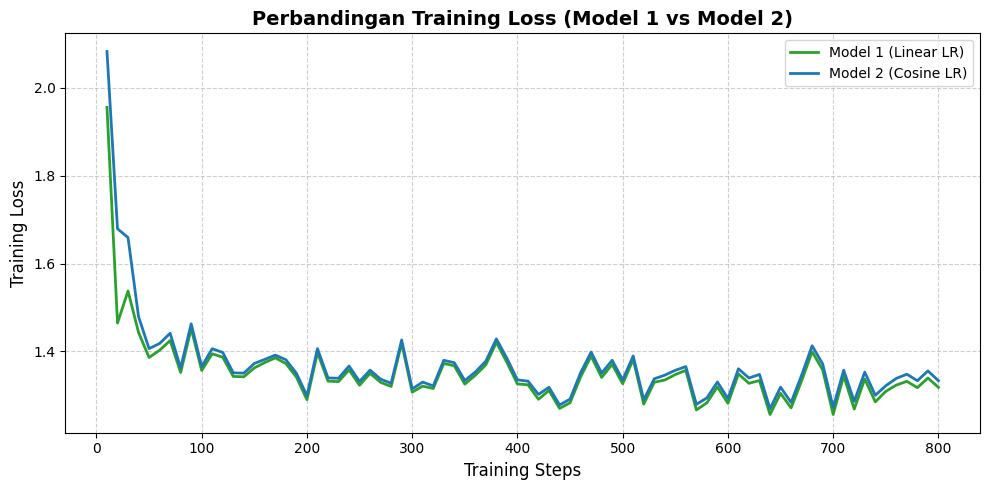


--- Tabel Perbandingan Metrik & Hyperparameter ---


,model,learning_rate,scheduler,max_steps,max_length,lora_r,lora_alpha,best_eval_loss,training_time_minutes
0,Model 1 (Linear),0.0002,SchedulerType.LINEAR,800,2048,16,16,1.297389,36.30
1,Model 2 (Cosine),0.0001,SchedulerType.COSINE,800,2048,16,16,1.310019,42.34



[KESIMPULAN] Model dengan eval_loss terbaik adalah: Model 1 (Linear)
[INFO] Gunakan model ini (ariefw666/qwen-finetuned-legal-16bit-model-1) untuk tahap RAG dan aplikasi AI selanjutnya!


In [16]:
# Sel 8: Evaluasi dan Perbandingan Eksperimen
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

print("==== KESIMPULAN EKSPERIMEN ====\n")

# 1. Membaca kembali aset metrik yang sudah disimpan (Reproducibility)
with open("outputs_exp_1/results/model_1_metrics.json", "r") as f:
    res_1 = json.load(f)
with open("outputs_exp_2/results/model_2_metrics.json", "r") as f:
    res_2 = json.load(f)

# 2. Menampilkan Ringkasan Teks (Di Atas Grafik)
print(f"--- Waktu Training ---")
print(f"Model 1 (Linear) : {res_1['training_time_seconds'] / 60:.2f} menit")
print(f"Model 2 (Cosine) : {res_2['training_time_seconds'] / 60:.2f} menit\n")

print(f"--- Best Evaluation Loss ---")
print(f"Model 1 (Linear) : {res_1['best_eval_loss']:.4f}")
print(f"Model 2 (Cosine) : {res_2['best_eval_loss']:.4f}\n")

# 3. Visualisasi Grafik Kurva Loss
steps_1 = [log["step"] for log in res_1["log_history"] if "loss" in log]
loss_1 = [log["loss"] for log in res_1["log_history"] if "loss" in log]

steps_2 = [log["step"] for log in res_2["log_history"] if "loss" in log]
loss_2 = [log["loss"] for log in res_2["log_history"] if "loss" in log]

plt.figure(figsize=(10, 5))
plt.plot(steps_1, loss_1, label='Model 1 (Linear LR)', color='#2ca02c', linewidth=2)
plt.plot(steps_2, loss_2, label='Model 2 (Cosine LR)', color='#1f77b4', linewidth=2)

plt.title('Perbandingan Training Loss (Model 1 vs Model 2)', fontsize=14, fontweight='bold')
plt.xlabel('Training Steps', fontsize=12)
plt.ylabel('Training Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Menampilkan grafik
plt.show()

# 4. Membuat Tabel Ringkasan Hyperparameter & Metrik (Pandas)
summary_df = pd.DataFrame([
    {
        "model": "Model 1 (Linear)",
        "learning_rate": args_1.learning_rate,
        "scheduler": args_1.lr_scheduler_type,
        "max_steps": args_1.max_steps,
        "max_length": args_1.max_seq_length,
        "lora_r": 16,
        "lora_alpha": 16,
        "best_eval_loss": res_1["best_eval_loss"],
        "training_time_minutes": round(res_1["training_time_seconds"] / 60, 2),
    },
    {
        "model": "Model 2 (Cosine)",
        "learning_rate": args_2.learning_rate,
        "scheduler": args_2.lr_scheduler_type,
        "max_steps": args_2.max_steps,
        "max_length": args_2.max_seq_length,
        "lora_r": 16,
        "lora_alpha": 16,
        "best_eval_loss": res_2["best_eval_loss"],
        "training_time_minutes": round(res_2["training_time_seconds"] / 60, 2),
    },
])

print("\n--- Tabel Perbandingan Metrik & Hyperparameter ---")
display(summary_df)

# 5. Menentukan Pemenang Otomatis
best_model_name = summary_df.sort_values("best_eval_loss").iloc[0]["model"]
print(f"\n[KESIMPULAN] Model dengan eval_loss terbaik adalah: {best_model_name}")
print(f"[INFO] Gunakan model ini (ariefw666/qwen-finetuned-legal-16bit-model-1) untuk tahap RAG dan aplikasi AI selanjutnya!")

#9. Uji Singkat Model

In [11]:
# Sel 9: Uji Singkat Model (Inference)
from transformers import TextStreamer

# 1. Mengaktifkan mode inference (mematikan kalkulasi gradient agar lebih cepat)
FastLanguageModel.for_inference(model_2)

print("Mempersiapkan pertanyaan...\n")
pertanyaan = "Jelaskan dengan singkat apa perbedaan antara hukum perdata dan hukum pidana di Indonesia."

# 2. Merakit format pesan (ChatML)
messages = [
    {"role": "system", "content": "Anda adalah asisten AI di bidang hukum yang cerdas, akurat, dan membantu."},
    {"role": "user", "content": pertanyaan}
]

# 3. Membungkus pesan dengan template
inputs = tokenizer_2.apply_chat_template(
    messages,
    tokenize = True,
    add_generation_prompt = True, # Penting: Memberi aba-aba agar asisten mulai menjawab
    return_tensors = "pt",
).to("cuda")

# 4. Menyiapkan efek streaming teks
text_streamer = TextStreamer(tokenizer_2, skip_prompt=True)

print("--- JAWABAN MODEL ---\n")
# 5. Generasi Jawaban
_ = model_2.generate(
    inputs,
    streamer = text_streamer,
    max_new_tokens = 250, # Batas panjang jawaban
    use_cache = True,
    temperature = 0.7, # Sedikit kreativitas (0.0 = kaku, 1.0 = sangat acak)
    top_p = 0.9
)
print("\n---------------------")
print("[SUCCESS] Pengujian Selesai!")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=250) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Mempersiapkan pertanyaan...

--- JAWABAN MODEL ---



/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


Hukum perdata dan hukum pidana adalah dua hukum yang berbeda dalam sistem hukum negara Indonesia. Hukum perdata melibatkan tindakan yang melanggar hak-hak individu, seperti pencurian, pencurian, dan pencurian anak. Hukum pidana, di sisi lain, melibatkan tindakan yang melanggar hukum negara, seperti pencurian, pencurian, dan pencurian anak. Namun, hukum perdata dan hukum pidana memiliki beberapa perbedaan. Hukum perdata lebih terkait dengan hak-hak individu, sedangkan hukum pidana lebih terkait dengan tindakan yang melanggar hukum negara. Selain itu, hukum perdata lebih sering diatur dalam hukum perdata, sedangkan hukum pidana lebih sering diatur dalam hukum pidana.<|im_end|>

---------------------
[SUCCESS] Pengujian Selesai!


In [15]:
# Sel Tambahan: Generate Exact Version requirements.txt
import importlib.metadata
from google.colab import files

print("Mendeteksi versi asli library di environment saat ini...\n")

# Daftar paket inti yang menyusun arsitektur Qwen & LoRA kita
core_packages = [
    "torch",
    "transformers",
    "accelerate",
    "bitsandbytes",
    "peft",
    "trl",
    "datasets",
    "wandb"
]

requirements_lines = ["# Versi Exact dari Environment Fine-Tuning Qwen\n"]

for pkg in core_packages:
    try:
        # Mengambil versi persis yang saat ini ter-install dan berjalan
        version = importlib.metadata.version(pkg)
        line = f"{pkg}=={version}"
        requirements_lines.append(line)
        print(f"[OK] {line}")
    except importlib.metadata.PackageNotFoundError:
        print(f"[WARNING] {pkg} tidak terdeteksi.")

# Khusus Unsloth, kita tetap menggunakan format GitHub karena instalasinya khusus Colab
requirements_lines.append("\n# Unsloth (Instalasi khusus via GitHub untuk Colab)")
requirements_lines.append("unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git")

# Menyimpan ke dalam file text
filename = "requirements_exact.txt"
with open(filename, "w") as f:
    f.write("\n".join(requirements_lines))

# Memicu unduhan otomatis
files.download(filename)
print(f"\n[SUCCESS] File {filename} dengan versi ASLI berhasil dibuat dan diunduh!")

Mendeteksi versi asli library di environment saat ini...

[OK] torch==2.11.0+cu128
[OK] transformers==5.5.0
[OK] accelerate==1.13.0
[OK] bitsandbytes==0.49.2
[OK] peft==0.19.1
[OK] trl==0.24.0
[OK] datasets==4.3.0
[OK] wandb==0.27.0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


[SUCCESS] File requirements_exact.txt dengan versi ASLI berhasil dibuat dan diunduh!
